In [ ]:
include("CRD_STA.jl")
include("Fun.jl")
using NonlinearEigenproblems
using DelimitedFiles
N_cheb = 49
Mr = 0.1
gamma = 1.4
sigma = 0.72
Ro = 1
Co = 0
Tw = 1
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co);
H,T = T_ca(Mr,f,q,w0,gamma,Tw);
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T;
kappa = (1/sigma) * T;
global data_all = [0 0 0 0]
global data_temp = []
for be = 0.2 : -0.005 : -0.15
    for R = 30 :  -0.5 : 20
        Ma = Mr/R
        PinPoint= []
        total = []
        writedlm("AS.dat",total)
        B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al0,be,N_cheb,Ro,Co)
        global C = eigen(B0,B1)
        global val = filter(x->-0.02<imag(x)<0.1&&abs(real(x))<0.2,C.values)
        if val == ComplexF64[]
            data_temp = [be R -1 -1]
            continue
        end 
        for i = 1 : min(3,length(val))
            indi = []
            val_temp = val[i]
            for al = 0.1 : 0.002 : 0.7
                vec = eigvector(val[i],C.values,C.vectors)
                B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
                val0,vec0 = RQI(B0,B1,val_temp,q0=vec)
                indi = [indi;val0]
                val_temp = val0
                vec = vec0 
                open("AS.dat", "a") do io
                write(io,"al = $al,eig = $val0\n")
                end
            end
            if i == 1
                total = indi
            else
                total = [total indi]
            end
        end
        for i = 1 : size(total,2)
            d2 = diff1(real(total[:,i]),0.002)
            for i = 1 : length(d2)-1
                if d2[i] * d2[i+1] < 0 && abs(d2[i+1])<0.005
                    PinPoint = [PinPoint;total[i,1]]
                end
            end
        end
        if PinPoint == []
            data_temp = [be R -1 -1]
        else
            data_temp = [be R real(PinPoint[findmax(imag(PinPoint))[2],1]) imag(PinPoint[findmax(imag(PinPoint))[2],1])]
        end
        data_all = [data_all;data_temp]
        writedlm("dataall.dat",data_all)
    end
end

InterruptException: InterruptException:

In [260]:
data_all

Any[]

In [250]:
PinPoint= []
d2 = diff1(real(total[:,1]),0.002)
for i = 1 : length(d2)-1
    if d2[i] * d2[i+1] < 0 && abs(d2[i+1])<0.005
        PinPoint = [PinPoint;total[i,1]]
    end
end
@show PinPoint

PinPoint = Any[-0.016249489971469574 - 0.006257641432771694im, -0.010680194319221766 + 0.003432320401390015im]


2-element Vector{Any}:
 -0.016249489971469574 - 0.006257641432771694im
 -0.010680194319221766 + 0.003432320401390015im

In [252]:
findmax(imag(PinPoint))[2]

2

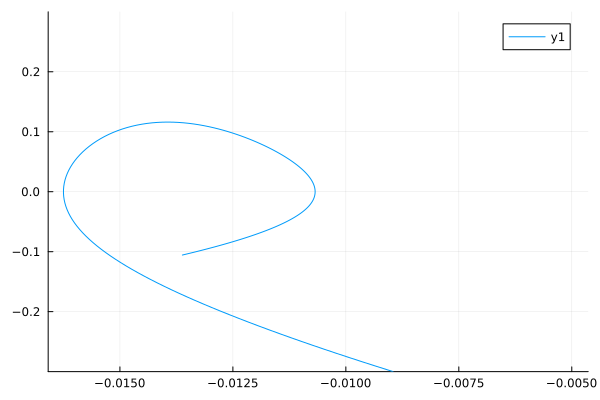

In [241]:
plot(real(total[:,1]),d2,ylims = [-0.3,0.3])

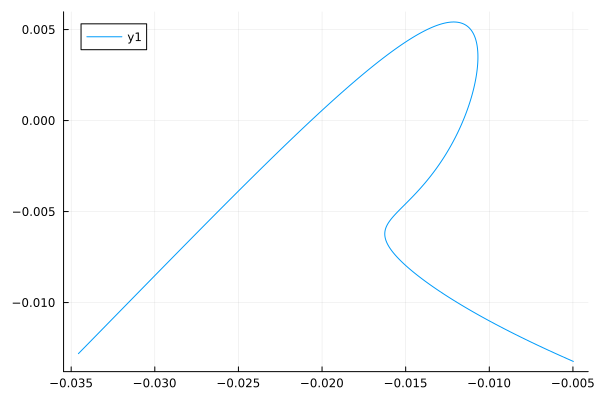

In [244]:
plot(real(total[:,1]),imag(total[:,1]))